<a href="https://colab.research.google.com/github/Nehjulbatool/Data-Science-Projects/blob/main/Stroke_Prediction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stroke Prediction and Risk Factor Analysis
This project aims to analyze patient data and predict the presence of Stroke using various health indicators.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('healthcare-dataset-stroke-data.csv')

## 1. Exploratory Data Analysis (EDA)

## 1.1 Data Inspection & Statistics

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.shape

(5110, 12)

In [ ]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [ ]:
df.columns=['id', 'gender', 'age', 'hypertension', 'heart_disease', 'married',
       'work_type', 'Residence_type', 'glucose_level', 'bmi',
       'smoking_status', 'stroke']
df.head()

,id,gender,age,hypertension,heart_disease,married,work_type,Residence_type,glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
# Dropping the 'id' column as it is not a significant feature for stroke prediction
df.drop('id', axis=1, inplace=True)

In [ ]:
df.describe

<bound method NDFrame.describe of       gender   age  hypertension  heart_disease married      work_type  \
0       Male  67.0             0              1     Yes        Private   
1     Female  61.0             0              0     Yes  Self-employed   
2       Male  80.0             0              1     Yes        Private   
3     Female  49.0             0              0     Yes        Private   
4     Female  79.0             1              0     Yes  Self-employed   
...      ...   ...           ...            ...     ...            ...   
5105  Female  80.0             1              0     Yes        Private   
5106  Female  81.0             0              0     Yes  Self-employed   
5107  Female  35.0             0              0     Yes  Self-employed   
5108    Male  51.0             0              0     Yes        Private   
5109  Female  44.0             0              0     Yes       Govt_job   

     Residence_type  glucose_level   bmi   smoking_status  stroke  
0        

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          5110 non-null   object 
 1   age             5110 non-null   float64
 2   hypertension    5110 non-null   int64  
 3   heart_disease   5110 non-null   int64  
 4   married         5110 non-null   object 
 5   work_type       5110 non-null   object 
 6   Residence_type  5110 non-null   object 
 7   glucose_level   5110 non-null   float64
 8   bmi             4909 non-null   float64
 9   smoking_status  5110 non-null   object 
 10  stroke          5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


 # 1.2 Data Visualization

## Q1: What is the distribution of Stroke in the dataset?

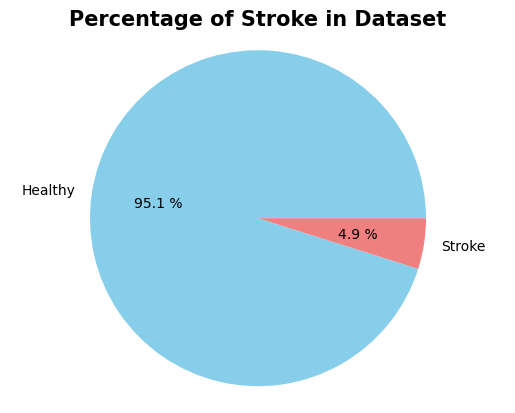

In [ ]:
# we take real counts from data
stroke_counts = df['stroke'].value_counts()
labels= ['Healthy', 'Stroke']
sizes = [stroke_counts[0], stroke_counts[1]] # 0 is Healthy, 1 is Stroke
colors= ['skyblue', 'lightcoral']
plt.pie(sizes, labels=labels, colors=colors, autopct= '%1.1f %%')
plt.title('Percentage of Stroke in Dataset', fontsize=15, weight='bold')
plt.axis('equal')
plt.show()

## Q2: What is the frequency of stroke occurrences across different genders?

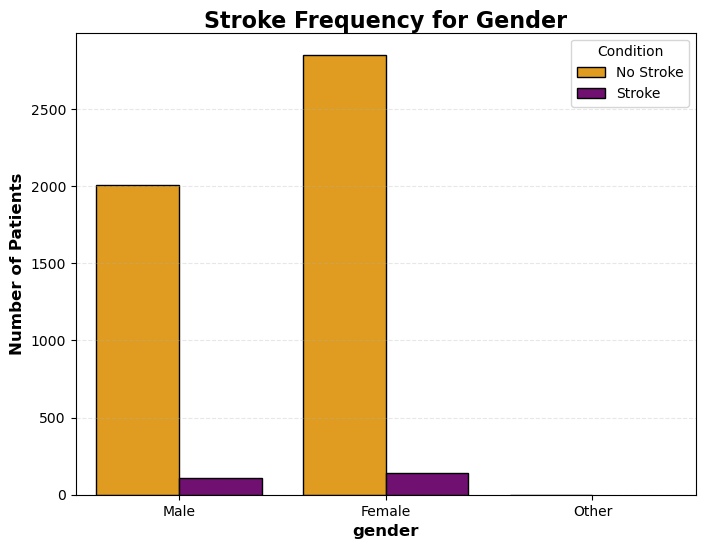

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', hue='stroke', data=df, palette=['orange', 'purple'], edgecolor='black')
plt.title('Stroke Frequency for Gender', fontsize=16, weight='bold', pad=3)
plt.xlabel('gender', fontsize=12, weight='semibold')
plt.ylabel('Number of Patients', fontsize=12, weight='semibold')
plt.legend(['No Stroke', 'Stroke'], loc='upper right', title='Condition')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Q3: What is the age distribution of the patients in the dataset?

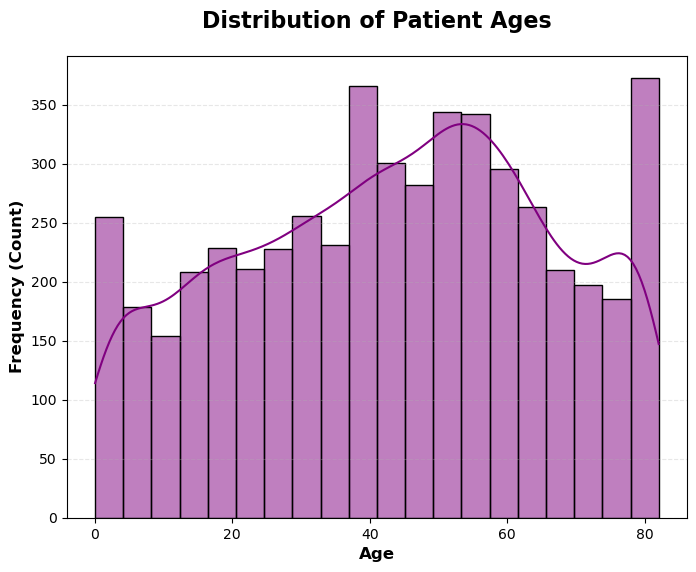

In [ ]:
plt.figure(figsize=(8, 6))

# Histogram which shows the distribution of age
sns.histplot(df['age'], bins=20, kde=True, color='purple', edgecolor='black')

plt.title('Distribution of Patient Ages', fontsize=16, weight='bold', pad=20)
plt.xlabel('Age', fontsize=12, weight='semibold')
plt.ylabel('Frequency (Count)', fontsize=12, weight='semibold')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

## Q4: What is the average age of patients who suffered a stroke?

In [ ]:
# 1.filtering the data of those who had stroke
stroke_patients = df[df['stroke'] == 1]
average_age_stroke = stroke_patients['age'].mean()
print(f"Average Age of Stroke Patients: {average_age_stroke:.2f} years")

Average Age of Stroke Patients: 67.73 years


## Q5: Which work type is most common among stroke patients?

In [ ]:
stroke_patients = df[df['stroke'] == 1]
work_counts = stroke_patients['work_type'].value_counts()
print("Work Type Counts for Stroke Patients:")
print(work_counts)
most_common_work = work_counts.idxmax()
print(f"\nThe most common work type among stroke patients is: {most_common_work}")

Work Type Counts for Stroke Patients:
work_type
Private          149
Self-employed     65
Govt_job          33
children           2
Name: count, dtype: int64

The most common work type among stroke patients is: Private


## 2. Data Pre-processing

In [ ]:
print("Missing Values in each column:")
print(df.isnull().sum())

Missing Values in each column:
gender              0
age                 0
hypertension        0
heart_disease       0
married             0
work_type           0
Residence_type      0
glucose_level       0
bmi               201
smoking_status      0
stroke              0
dtype: int64


In [ ]:
# Filling missing BMI values with the mean to maintain data consistency
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())
# Verify that there are no more null values
print("Null values count:", df['bmi'].isnull().sum())

Null values count: 0


In [ ]:
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")


Number of duplicate rows found: 0


## 2.1 Encoding & Unique Value Check

In [ ]:
print("Unique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unique values in each column:
gender: 3 unique values
age: 104 unique values
hypertension: 2 unique values
heart_disease: 2 unique values
married: 2 unique values
work_type: 5 unique values
Residence_type: 2 unique values
glucose_level: 3979 unique values
bmi: 419 unique values
smoking_status: 4 unique values
stroke: 2 unique values


## a)Feature Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Converting text categories into numbers (0 and 1)
# Even if there are no nulls, encoding is required for the model to understand text
binary_cols = ['married', 'Residence_type']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

## b) One-Hot Encoding

In [ ]:
#One-Hot Encoding for categories with more than 2 options
df = pd.get_dummies(df, columns=['gender', 'work_type', 'smoking_status'], drop_first=True)

# Final check to ensure all columns are now numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5110 non-null   float64
 1   hypertension                    5110 non-null   int64  
 2   heart_disease                   5110 non-null   int64  
 3   married                         5110 non-null   int64  
 4   Residence_type                  5110 non-null   int64  
 5   glucose_level                   5110 non-null   float64
 6   bmi                             5110 non-null   float64
 7   stroke                          5110 non-null   int64  
 8   gender_Male                     5110 non-null   bool   
 9   gender_Other                    5110 non-null   bool   
 10  work_type_Never_worked          5110 non-null   bool   
 11  work_type_Private               5110 non-null   bool   
 12  work_type_Self-employed         51

## 2.2 Outlier Detection & Removal

In [ ]:
# Removing outliers using the Interquartile Range (IQR) method to ensure the model is not skewed by extreme values in BMI and Glucose levels.
features_with_outliers = ['bmi', 'glucose_level']
for feature in features_with_outliers:
# Removing Q1 (25th percentile) and Q3 (75th percentile):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]
print("Outliers removed successfully using Interquartile Range (IQR) method.")
print("New shape of dataset:", df.shape)

Outliers removed successfully using Interquartile Range (IQR) method.
New shape of dataset: (4377, 17)


# 3. Machine Learning

## 3.1 Splitting

In [ ]:
# Splitting the Data into Training and Testing Sets ---

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Defining features (X) and target variable (y)
X = df.drop(columns=['stroke'])
y = df['stroke']

# Splitting the dataset (80% for training and 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3.2 Model Training and Overfitting Check

In [ ]:
# Initializing and training the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# Predicting on both training and testing sets to check for overfitting
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## 3.3 Calculating Accuracy

In [ ]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

# Logic to identify overfitting
if train_accuracy > test_accuracy + 0.1:
    print("Warning: The model might be Overfitting.")
else:
    print("The model is performing well on both sets (No significant Overfitting).")

Training Accuracy: 96.34%
Testing Accuracy: 95.89%
The model is performing well on both sets (No significant Overfitting).


## 3.4 Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Training data par fit aur transform karna
X_train_scaled = scaler.fit_transform(X_train)

# Testing data ko sirf transform karna
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed. Ready for final evaluation.")

Feature scaling completed. Ready for final evaluation.


# 4.Model Evaluation

In [ ]:
# Generating predictions using the scaled testing data
y_pred = model.predict(X_test_scaled)

C:\Users\ADIL TRADERS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


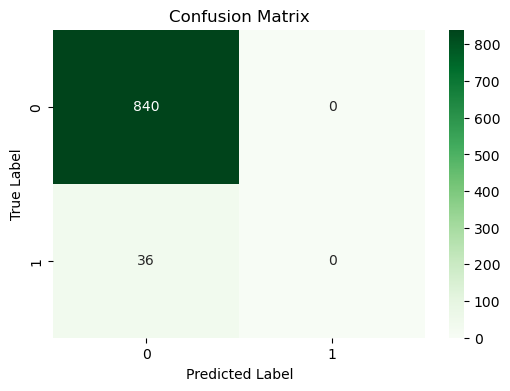

In [ ]:
# Confusion matrics
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       840
           1       0.00      0.00      0.00        36

    accuracy                           0.96       876
   macro avg       0.48      0.50      0.49       876
weighted avg       0.92      0.96      0.94       876



C:\Users\ADIL TRADERS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADIL TRADERS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADIL TRADERS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 5. Application (Predicting on User Data)

In [ ]:
# --- 5. Application: Real-time Prediction (Fixed) ---
import pandas as pd

print("--- Stroke Risk Prediction System ---")

# 1. Collect the 5 basic inputs
age = float(input("Enter Age: "))
glucose = float(input("Enter Average Glucose Level: "))
bmi = float(input("Enter BMI: "))
hypertension = int(input("Hypertension (1 for Yes, 0 for No): "))
heart_disease = int(input("Heart Disease (1 for Yes, 0 for No): "))

# 2. Create a DataFrame with ALL 16 columns from your training data 'X'
# This fills all 16 columns with 0 by default
user_input_df = pd.DataFrame(0, index=[0], columns=X.columns)

# 3. Fill in only the 5 values we collected
user_input_df['age'] = age
user_input_df['glucose_level'] = glucose
user_input_df['bmi'] = bmi
user_input_df['hypertension'] = hypertension
user_input_df['heart_disease'] = heart_disease

# 4. Now Scale
user_data_scaled = scaler.transform(user_input_df)

# 5. Predict
prediction = model.predict(user_data_scaled)

print("\n--- Prediction Result ---")
if prediction[0] == 1:
    print("Warning: High risk of Stroke.")
else:
    print("Result: Low risk of Stroke.")

--- Stroke Risk Prediction System ---


Enter Age:  19
Enter Average Glucose Level:  200
Enter BMI:  43
Hypertension (1 for Yes, 0 for No):  0
Heart Disease (1 for Yes, 0 for No):  0



--- Prediction Result ---
Result: Low risk of Stroke.


C:\Users\ADIL TRADERS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Conclusion:-